In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")

In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
import equinox as eqx
from cycler import cycler
import palettable
import seaborn as sns
import time

from ABCMB import main, background, perturbations, spectrum, model_specs, species
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

ERROR:2026-01-25 18:21:21,128:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


# Specs

In [4]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

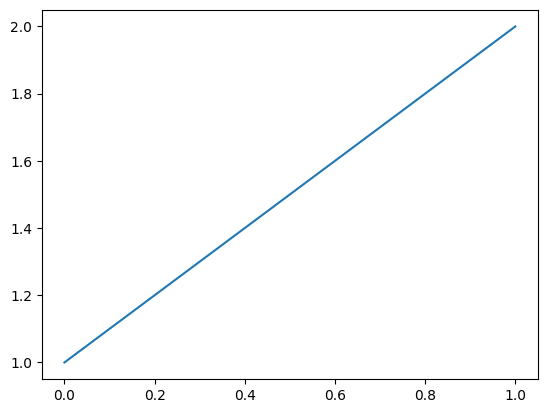

In [5]:
import matplotlib.pyplot as plt
plt.plot([1, 2])
plt.show()

In [6]:
params = {'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
        #   'animation.avconv_args': [],
        #   'animation.avconv_path': 'avconv',
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': [],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
        #   'animation.html_args': [],
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-7, 7],
          'axes.formatter.min_exponent': 2,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
          'axes.grid.which': 'major',
          'axes.labelcolor': 'black',
          'axes.labelpad': 10.0,
          'axes.labelsize': 19.0,
          'axes.labelweight': 'normal',
          'axes.linewidth': 1.8,
          'axes.prop_cycle': cycler('color', sns.color_palette("Set1", 10, desat=0.7).as_hex()) + 
                            cycler(alpha=10*[.9]), 
          # 'axes.prop_cycle': cycler('color', sns.color_palette('husl', 10).as_hex()),
          'axes.spines.bottom': True,
          'axes.spines.left': True,
          'axes.spines.right': True,
          'axes.spines.top': True,
          'axes.titlepad': 7.5,
          'axes.titlesize': 18.0,
          'axes.titleweight': 'normal',
          'axes.unicode_minus': True,
          'axes.xmargin': 0.05,
          'axes.ymargin': 0.05,
          'axes3d.grid': True,
          #'backend': 'module://ipykernel.pylab.backend_inline',
          'backend_fallback': True,
          'boxplot.bootstrap': None,
          'boxplot.boxprops.color': 'black',
          'boxplot.boxprops.linestyle': '-',
          'boxplot.boxprops.linewidth': 1.0,
          'boxplot.capprops.color': 'black',
          'boxplot.capprops.linestyle': '-',
          'boxplot.capprops.linewidth': 1.0,
          'boxplot.flierprops.color': 'black',
          'boxplot.flierprops.linestyle': 'none',
          'boxplot.flierprops.linewidth': 1.0,
          'boxplot.flierprops.marker': 'o',
          'boxplot.flierprops.markeredgecolor': 'black',
          'boxplot.flierprops.markerfacecolor': 'none',
          'boxplot.flierprops.markersize': 6.0,
          'boxplot.meanline': False,
          'boxplot.meanprops.color': 'C2',
          'boxplot.meanprops.linestyle': '--',
          'boxplot.meanprops.linewidth': 1.0,
          'boxplot.meanprops.marker': '^',
          'boxplot.meanprops.markeredgecolor': 'C2',
          'boxplot.meanprops.markerfacecolor': 'C2',
          'boxplot.meanprops.markersize': 6.0,
          'boxplot.medianprops.color': 'C1',
          'boxplot.medianprops.linestyle': '-',
          'boxplot.medianprops.linewidth': 1.0,
          'boxplot.notch': False,
          'boxplot.patchartist': False,
          'boxplot.showbox': True,
          'boxplot.showcaps': True,
          'boxplot.showfliers': True,
          'boxplot.showmeans': False,
          'boxplot.vertical': True,
          'boxplot.whiskerprops.color': 'black',
          'boxplot.whiskerprops.linestyle': '-',
          'boxplot.whiskerprops.linewidth': 1.0,
          'boxplot.whiskers': 1.5,
          'contour.corner_mask': True,
          'contour.negative_linestyle': 'dashed',
          # 'datapath': '/Users/smsharma/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data',
          'date.autoformatter.day': '%Y-%m-%d',
          'date.autoformatter.hour': '%m-%d %H',
          'date.autoformatter.microsecond': '%M:%S.%f',
          'date.autoformatter.minute': '%d %H:%M',
          'date.autoformatter.month': '%Y-%m',
          'date.autoformatter.second': '%H:%M:%S',
          'date.autoformatter.year': '%Y',
          'docstring.hardcopy': False,
          'errorbar.capsize': 0.0,
          'figure.autolayout': False,
          'figure.constrained_layout.h_pad': 0.04167,
          'figure.constrained_layout.hspace': 0.02,
          'figure.constrained_layout.use': False,
          'figure.constrained_layout.w_pad': 0.04167,
          'figure.constrained_layout.wspace': 0.02,
          'figure.dpi': 72.0,
          'figure.edgecolor': (1, 1, 1, 0),
          'figure.facecolor': (1, 1, 1, 0),
          'figure.figsize': [6.153846153846153, 5.0],
          'figure.frameon': True,
          'figure.max_open_warning': 20,
          'figure.subplot.bottom': 0.125,
          'figure.subplot.hspace': 0.2,
          'figure.subplot.left': 0.125,
          'figure.subplot.right': 0.9,
          'figure.subplot.top': 0.88,
          'figure.subplot.wspace': 0.2,
          'figure.titlesize': 'large',
          'figure.titleweight': 'normal',
          'font.cursive': ['Apple Chancery',
                           'Textile',
                           'Zapf Chancery',
                           'Sand',
                           'Script MT',
                           'Felipa',
                           'cursive'],
          'font.family': ['serif'],
          'font.fantasy': ['Comic Sans MS',
                           'Chicago',
                           'Charcoal',
                           'Impact',
                           'Western',
                           'Humor Sans',
                           'xkcd',
                           'fantasy'],
          'font.monospace': ['DejaVu Sans Mono',
                             'Bitstream Vera Sans Mono',
                             'Computer Modern Typewriter',
                             'Andale Mono',
                             'Nimbus Mono L',
                             'Courier New',
                             'Courier',
                             'Fixed',
                             'Terminal',
                             'monospace'],
          'font.sans-serif': ['CMU Sans Serif'],
          'font.serif': ['CMU Serif'],
          'font.size': 10.0,
          'font.stretch': 'normal',
          'font.style': 'normal',
          'font.variant': 'normal',
          'font.weight': 'normal',
          'grid.alpha': 1.0,
          'grid.color': '#b0b0b0',
          'grid.linestyle': '-',
          'grid.linewidth': 0.8,
          'hatch.color': 'black',
          'hatch.linewidth': 1.0,
          'hist.bins': 10,
          'image.aspect': 'equal',
          'image.cmap': 'viridis',
          'image.composite_image': True,
          'image.interpolation': 'nearest',
          'image.lut': 256,
          'image.origin': 'upper',
          'image.resample': True,
          'interactive': True,
        #   'keymap.all_axes': ['a'],
          'keymap.back': ['left', 'c', 'backspace'],
          'keymap.copy': ['ctrl+c', 'cmd+c'],
          'keymap.forward': ['right', 'v'],
          'keymap.fullscreen': ['f', 'ctrl+f'],
          'keymap.grid': ['g'],
          'keymap.grid_minor': ['G'],
          'keymap.help': ['f1'],
          'keymap.home': ['h', 'r', 'home'],
          'keymap.pan': ['p'],
          'keymap.quit': ['ctrl+w', 'cmd+w', 'q'],
          'keymap.quit_all': ['W', 'cmd+W', 'Q'],
          'keymap.save': ['s', 'ctrl+s'],
          'keymap.xscale': ['k', 'L'],
          'keymap.yscale': ['l'],
          'keymap.zoom': ['o'],
          'legend.borderaxespad': 0.5,
          'legend.borderpad': 0.4,
          'legend.columnspacing': 2.0,
          'legend.edgecolor': '0.8',
          'legend.facecolor': 'inherit',
          'legend.fancybox': True,
          'legend.fontsize': 17.0,
          'legend.framealpha': 0.4,
          'legend.frameon': False,
          'legend.handleheight': 0.7,
          'legend.handlelength': 2.0,
          'legend.handletextpad': 0.8,
          'legend.labelspacing': 0.5,
          'legend.loc': 'best',
          'legend.markerscale': 1.0,
          'legend.numpoints': 1,
          'legend.scatterpoints': 1,
          'legend.shadow': False,
          'legend.title_fontsize': None,
          'lines.antialiased': True,
          'lines.color': 'C0',
          'lines.dash_capstyle': 'butt',
          'lines.dash_joinstyle': 'round',
          'lines.dashdot_pattern': [6.4, 1.6, 1.0, 1.6],
          'lines.dashed_pattern': [3.7, 1.6],
          'lines.dotted_pattern': [1.0, 1.65],
          'lines.linestyle': '-',
          'lines.linewidth': 2.5,
          'lines.marker': 'None',
          'lines.markeredgecolor': 'auto',
          'lines.markeredgewidth': 1.0,
          'lines.markerfacecolor': 'auto',
          'lines.markersize': 6.0,
          'lines.scale_dashes': True,
          'lines.solid_capstyle': 'projecting',
          'lines.solid_joinstyle': 'round',
          'markers.fillstyle': 'full',
          'mathtext.bf': 'sans:bold',
          'mathtext.cal': 'cursive',
          'mathtext.default': 'it',
        #   'mathtext.fallback_to_cm': True,
          'mathtext.fontset': 'dejavusans',
          'mathtext.it': 'sans:italic',
          'mathtext.rm': 'sans',
          'mathtext.sf': 'sans',
          'mathtext.tt': 'monospace',
          'patch.antialiased': True,
          'patch.edgecolor': 'black',
          'patch.facecolor': 'C0',
          'patch.force_edgecolor': False,
          'patch.linewidth': 1.0,
          'path.effects': [],
          'path.simplify': True,
          'path.simplify_threshold': 0.1111111111111111,
          'path.sketch': None,
          'path.snap': True,
          'pdf.compression': 6,
          'pdf.fonttype': 3,
          'pdf.inheritcolor': False,
          'pdf.use14corefonts': False,
          # 'pgf.preamble': [],
          'pgf.rcfonts': True,
          'pgf.texsystem': 'xelatex',
          'polaraxes.grid': True,
          'ps.distiller.res': 6000,
          'ps.fonttype': 3,
          'ps.papersize': 'letter',
          'ps.useafm': False,
          'ps.usedistiller': False,
          'savefig.bbox': None,
          'savefig.directory': '~',
          'savefig.dpi': 'figure',
          'savefig.edgecolor': 'white',
          'savefig.facecolor': 'white',
          'savefig.format': 'png',
        #   'savefig.jpeg_quality': 95,
          'savefig.orientation': 'portrait',
          'savefig.pad_inches': 0.1,
          'savefig.transparent': False,
          'scatter.marker': 'o',
          'svg.fonttype': 'path',
          'svg.hashsalt': None,
          'svg.image_inline': True,
          'text.antialiased': True,
          'text.color': 'black',
          'text.hinting': 'auto',
          'text.hinting_factor': 8,
          # 'text.latex.preamble': [],
        #   'text.latex.preview': False,
          'text.usetex': True,
          'timezone': 'UTC',
          'tk.window_focus': False,
          'toolbar': 'toolbar2',
          'webagg.address': '127.0.0.1',
          'webagg.open_in_browser': True,
          'webagg.port': 8988,
          'webagg.port_retries': 50,
          'xtick.alignment': 'center',
          'xtick.bottom': True,
          'xtick.color': 'black',
          'xtick.direction': 'in',
          'xtick.labelbottom': True,
          'xtick.labelsize': 17.5,
          'xtick.labeltop': False,
          'xtick.major.bottom': True,
          'xtick.major.pad': 6.0,
          'xtick.major.size': 7.0,
          'xtick.major.top': True,
          'xtick.major.width': 1.0,
          'xtick.minor.bottom': True,
          'xtick.minor.pad': 3.4,
          'xtick.minor.size': 3.0,
          'xtick.minor.top': True,
          'xtick.minor.visible': True,
          'xtick.minor.width': 0.8,
          'xtick.top': True,
          'ytick.alignment': 'center_baseline',
          'ytick.color': 'black',
          'ytick.direction': 'in',
          'ytick.labelleft': True,
          'ytick.labelright': False,
          'ytick.labelsize': 17.5,
          'ytick.left': True,
          'ytick.major.left': True,
          'ytick.major.pad': 6.0,
          'ytick.major.right': True,
          'ytick.major.size': 7.0,
          'ytick.major.width': 1.0,
          'ytick.minor.left': True,
          'ytick.minor.pad': 3.4,
          'ytick.minor.right': True,
          'ytick.minor.size': 3.0,
          'ytick.minor.visible': True,
          'ytick.minor.width': 0.8,
          'ytick.right': True}
import matplotlib
for key, value in params.items():
    matplotlib.rcParams[key] = value
import matplotlib.pyplot as plt

# Random Params Comparison

In [8]:
path = "/home/zz1994/packages/ABCMB/comparison_scripts/out/5sigma"
l = np.loadtxt(path+"/unlensed/l.txt")
k = np.loadtxt(path+"/unlensed/k.txt")

In [9]:
tt = np.loadtxt(path+"/unlensed/tt.txt")
ee = np.loadtxt(path+"/unlensed/ee.txt")
Pk = np.loadtxt(path+"/unlensed/Pk.txt")

tt_lensed = np.loadtxt(path+"/lensed/tt.txt")
ee_lensed = np.loadtxt(path+"/lensed/ee.txt")

tt_mnu = np.loadtxt(path+"/mnu/tt.txt")
ee_mnu = np.loadtxt(path+"/mnu/ee.txt")
Pk_mnu = np.loadtxt(path+"/mnu/Pk.txt")

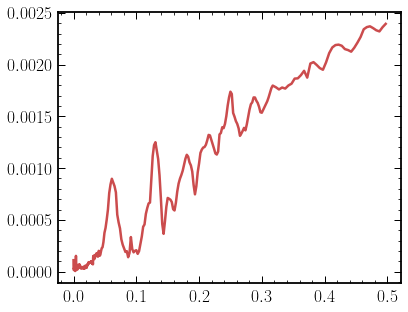

In [13]:
plt.plot(k, Pk)
plt.show()

# Params

In [8]:
params_lcdm = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

params_mnu = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'N_nu_massive': 1,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

# CLASS Benchmark

## $\Lambda {\rm CDM}$

In [9]:
class_lcdm_unlensed_params = {
    "output": "mPk, tCl, pCl",
    "P_k_max_1/Mpc" : 0.4,
    "l_max_scalars" : 2500,
    "lensing" : "no",
    "H0": params_lcdm["h"]*100,
    "omega_b": params_lcdm["omega_b"],
    "omega_cdm": params_lcdm["omega_cdm"],
    "A_s" : params_lcdm["A_s"],
    "n_s" : params_lcdm["n_s"],
    "N_ur": params_lcdm["Neff"],
    "YHe": params_lcdm["YHe"],
    "N_ncdm": 0,
    "reio_parametrization" : "reio_camb",
    "z_reio" : params_lcdm["z_reion"],
    "reionization_width" : params_lcdm["Delta_z_reion"],
    "helium_fullreio_redshift" : params_lcdm["z_reion_He"],
    "helium_fullreio_width" : params_lcdm["Delta_z_reion_He"],
    "reionization_exponent" : 1.5,
    "l_max_g": 12,
    "l_max_pol_g": 10,
    "l_max_ur": 17, 
    "l_max_ncdm": 17,
    "radiation_streaming_trigger_tau_over_tau_k" : 20000,
    "radiation_streaming_trigger_tau_c_over_tau" : 2000,
    "ur_fluid_trigger_tau_over_tau_k" : 10000, 
    "ncdm_fluid_trigger_tau_over_tau_k" : 15000} 

class_lcdm_unlensed = Class()
class_lcdm_unlensed.set(class_lcdm_unlensed_params)
class_lcdm_unlensed.compute()

In [10]:
class_lcdm_lensed_params = class_lcdm_unlensed_params.copy()
class_lcdm_lensed_params["output"] = "mPk, tCl, pCl, lCl"
class_lcdm_lensed_params["lensing"] = "yes"

class_lcdm_lensed = Class()
class_lcdm_lensed.set(class_lcdm_lensed_params)
class_lcdm_lensed.compute()

## Massive Neutrino

In [11]:
class_mnu_params = class_lcdm_lensed_params.copy()
class_mnu_params["N_ur"] = 2.0308
class_mnu_params["N_ncdm"] = 1
class_mnu_params["T_ncdm"] = 0.71611
class_mnu_params["m_ncdm"] = 0.06

class_mnu = Class()
class_mnu.set(class_mnu_params)
class_mnu.compute()

# ABCMB

## $\Lambda {\rm CDM}$

In [12]:
specs_unlensed = {
    "output_Cl" : True,
    "lensing" : False,
    "output_Pk" : True,
    "output_k_max" : 0.4,
}
specs_lensed = specs_unlensed.copy()
specs_lensed["lensing"] = True

abcmb_lcdm_unlensed = main.Model(specs_unlensed)
abcmb_lcdm_lensed = main.Model(specs_lensed)

In [13]:
output_lcdm_unlensed, aux_lcdm_unlensed = abcmb_lcdm_unlensed.run_cosmology(params_lcdm)
output_lcdm_lensed, aux_lcdm_lensed = abcmb_lcdm_lensed.run_cosmology(params_lcdm)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



## Massive Neutrino

In [14]:
user_species = (species.MassiveNeutrino,)
abcmb_mnu = main.Model(specs_lensed, user_species=user_species)

In [15]:
output_mnu, aux_mnu = abcmb_mnu.run_cosmology(params_mnu)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



# Comparison

In [16]:
l = aux_mnu[0]
cl_fac = l * (l+1) /2 /jnp.pi * (2.7255)**2 * 1.e12

## $\Lambda {\rm CDM}$ Unlensed

In [99]:
l = aux_lcdm_unlensed[0]
tt = output_lcdm_unlensed[0] * cl_fac
te = output_lcdm_unlensed[1] * cl_fac
ee = output_lcdm_unlensed[2] * cl_fac

k = aux_lcdm_unlensed[1]
Pk = output_lcdm_unlensed[3]

class_Pk = np.vectorize(class_lcdm_unlensed.pk)(k, 0)
class_tt = class_lcdm_unlensed.raw_cl(l[-1])["tt"][2:]*cl_fac
class_te = class_lcdm_unlensed.raw_cl(l[-1])["tt"][2:]*cl_fac
class_ee = class_lcdm_unlensed.raw_cl(l[-1])["ee"][2:]*cl_fac

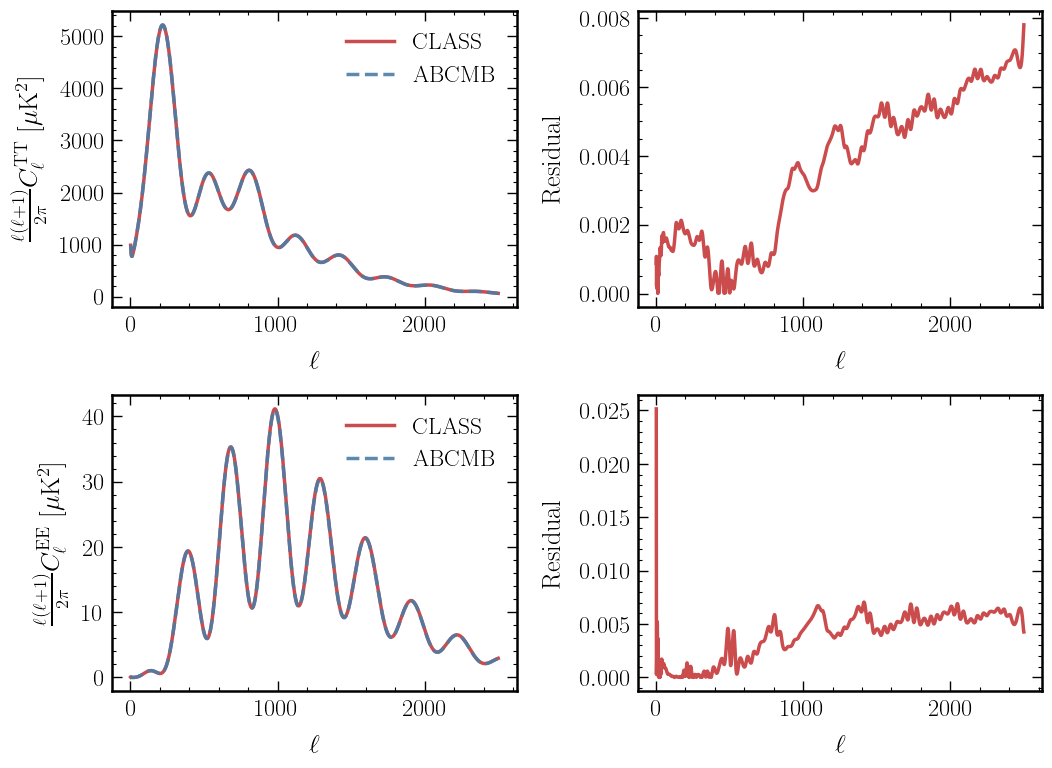

In [102]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.3)  # default ~0.2
axs[0, 0].plot(l, class_tt, label="CLASS")
axs[0, 0].plot(l, tt, "--", label="ABCMB")
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}C_\ell^{{\rm TT}}\ [\mu {\rm K}^2]$")
axs[0, 0].legend()

axs[0, 1].plot(l, abs(tt/class_tt-1))
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel("Residual")

axs[1, 0].plot(l, class_ee, label="CLASS")
axs[1, 0].plot(l, ee, "--", label="ABCMB")
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}C_\ell^{{\rm EE}}\ [\mu {\rm K}^2]$")
axs[1, 0].legend()

axs[1, 1].plot(l, abs(ee/class_ee-1))
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel("Residual")
#plt.savefig("Plots/Cl_unlensed.pdf", bbox_inches="tight")
plt.show()

## $\Lambda {\rm CDM}$ Lensed

In [53]:
l = aux_lcdm_lensed[0]
tt = output_lcdm_lensed[0] * cl_fac
te = output_lcdm_lensed[1] * cl_fac
ee = output_lcdm_lensed[2] * cl_fac

class_tt = class_lcdm_lensed.lensed_cl(l[-1])["tt"][2:]*cl_fac
class_te = class_lcdm_lensed.lensed_cl(l[-1])["te"][2:]*cl_fac
class_ee = class_lcdm_lensed.lensed_cl(l[-1])["ee"][2:]*cl_fac

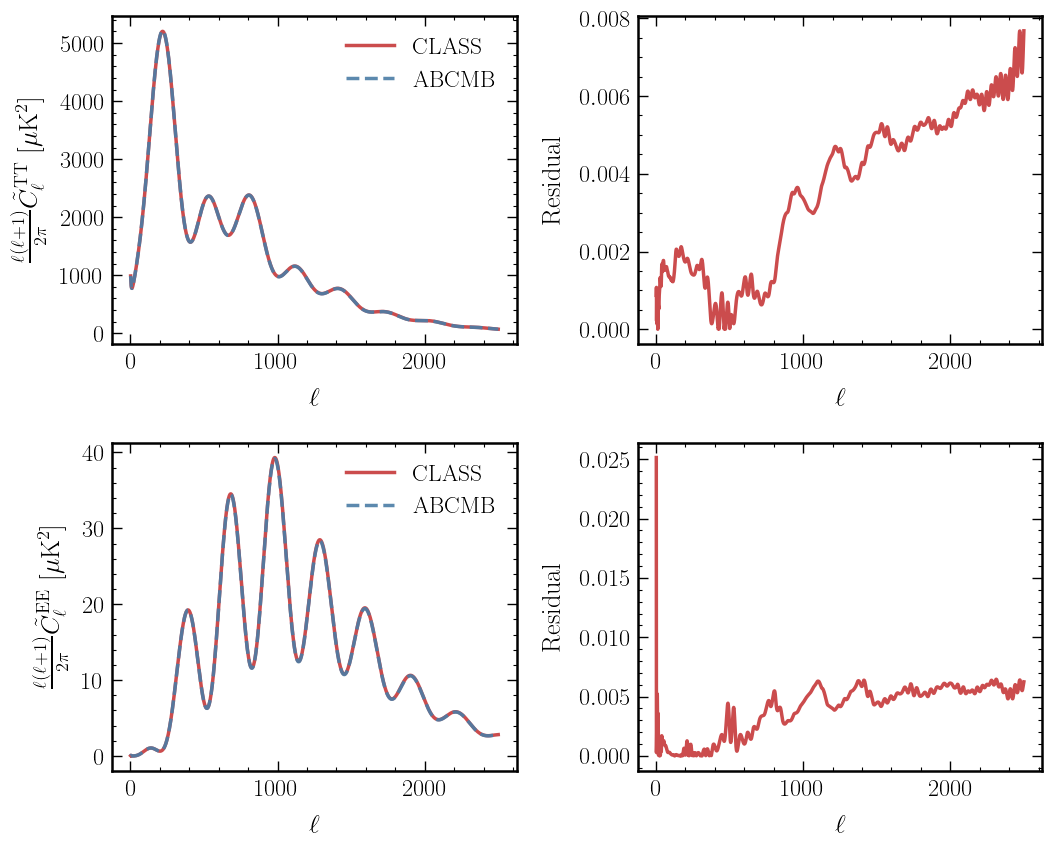

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.3)  # default ~0.2
axs[0, 0].plot(l, class_tt, label="CLASS")
axs[0, 0].plot(l, tt, "--", label="ABCMB")
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\tilde{C}_\ell^{{\rm TT}}\ [\mu {\rm K}^2]$")
axs[0, 0].legend()

axs[0, 1].plot(l, abs(tt/class_tt-1))
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel("Residual")

axs[1, 0].plot(l, class_ee, label="CLASS")
axs[1, 0].plot(l, ee, "--", label="ABCMB")
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\tilde{C}_\ell^{{\rm EE}}\ [\mu {\rm K}^2]$")
axs[1, 0].legend()

axs[1, 1].plot(l, abs(ee/class_ee-1))
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel("Residual")
plt.savefig("Plots/Cl_lensed.pdf", bbox_inches="tight")
plt.show()

## Massive Neutrino

In [56]:
l = aux_mnu[0]
tt = output_mnu[0] * cl_fac
te = output_mnu[1] * cl_fac
ee = output_mnu[2] * cl_fac
k = aux_mnu[1]
Pk = output_mnu[3]

class_Pk = np.vectorize(class_mnu.pk)(k, 0)
class_tt = class_mnu.lensed_cl(l[-1])["tt"][2:]*cl_fac
class_te = class_mnu.lensed_cl(l[-1])["te"][2:]*cl_fac
class_ee = class_mnu.lensed_cl(l[-1])["ee"][2:]*cl_fac

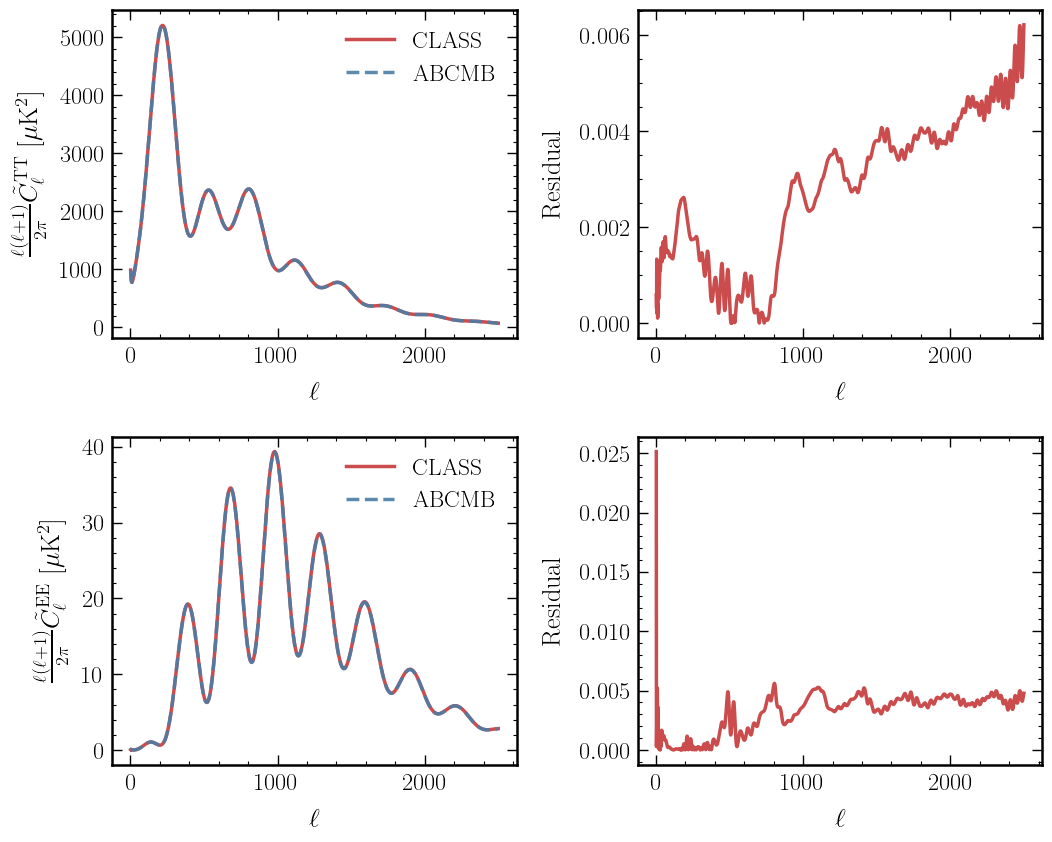

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.3)  # default ~0.2
axs[0, 0].plot(l, class_tt, label="CLASS")
axs[0, 0].plot(l, tt, "--", label="ABCMB")
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\tilde{C}_\ell^{{\rm TT}}\ [\mu {\rm K}^2]$")
axs[0, 0].legend()

axs[0, 1].plot(l, abs(tt/class_tt-1))
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel("Residual")

axs[1, 0].plot(l, class_ee, label="CLASS")
axs[1, 0].plot(l, ee, "--", label="ABCMB")
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\tilde{C}_\ell^{{\rm EE}}\ [\mu {\rm K}^2]$")
axs[1, 0].legend()

axs[1, 1].plot(l, abs(ee/class_ee-1))
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel("Residual")
plt.savefig("Plots/Cl_mnu.pdf", bbox_inches="tight")
plt.show()

## Matter Power Spectrum

In [59]:
k = aux_lcdm_unlensed[1]
Pk = output_lcdm_unlensed[3]
class_Pk = np.vectorize(class_lcdm_unlensed.pk)(k, 0)

Pk_mnu = output_mnu[3]
class_Pk_mnu = np.vectorize(class_mnu.pk)(k, 0)

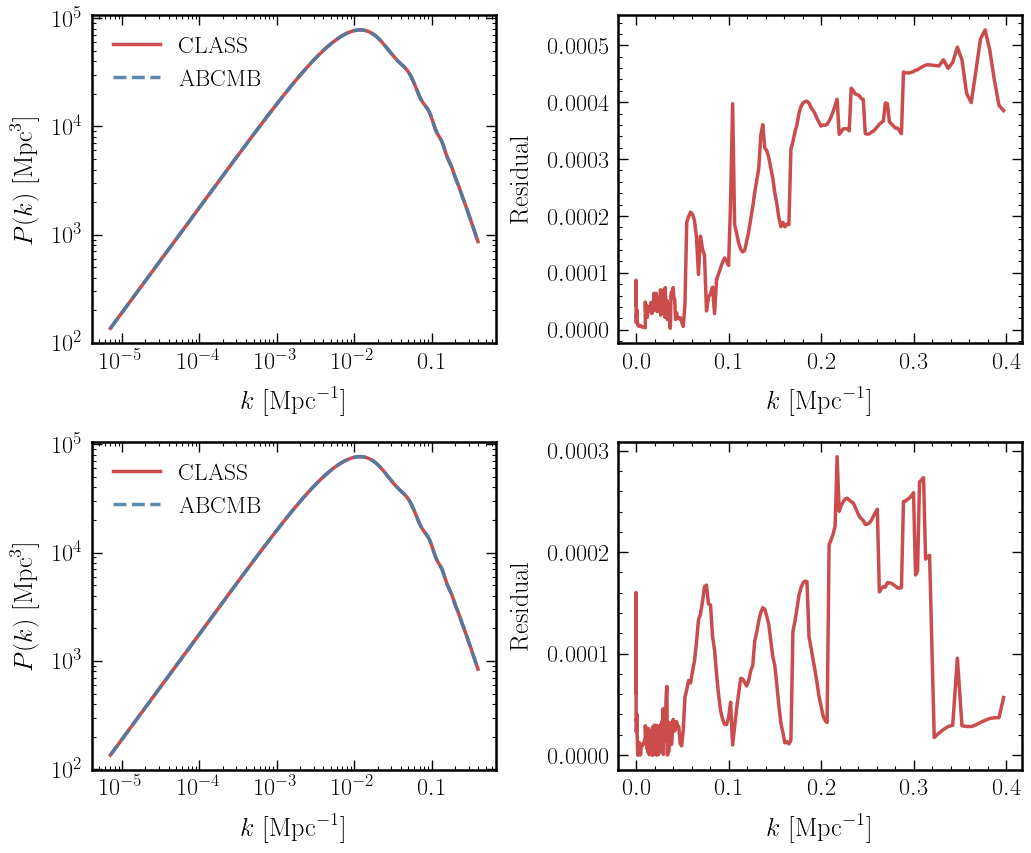

In [61]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.3)  # default ~0.2
axs[0, 0].loglog(k, class_Pk, label="CLASS")
axs[0, 0].loglog(k, Pk, "--", label="ABCMB")
axs[0, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 0].set_ylabel(r"$P(k)\ [{\rm Mpc}^3]$")
axs[0, 0].legend()

axs[0, 1].plot(k, abs(Pk/class_Pk-1))
axs[0, 1].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 1].set_ylabel("Residual")

axs[1, 0].loglog(k, class_Pk_mnu, label="CLASS")
axs[1, 0].loglog(k, Pk_mnu, "--", label="ABCMB")
axs[1, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[1, 0].set_ylabel(r"$P(k)\ [{\rm Mpc}^3]$")
axs[1, 0].legend()

axs[1, 1].plot(k, abs(Pk_mnu/class_Pk_mnu-1))
axs[1, 1].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[1, 1].set_ylabel("Residual")
plt.savefig("Plots/Pk.pdf", bbox_inches="tight")
plt.show()

# Gradient

## Without LINX

In [16]:
specs =specs_unlensed.copy()
specs["bbn_type"] = ""
model = main.Model(specs)
params_lcdm = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'YHe': 0.245,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

In [17]:
def f(h, omega_cdm, omega_b, A_s, n_s, YHe):
    params = params_lcdm.copy()
    params["h"] = h
    params["omega_cdm"] = omega_cdm
    params["omega_b"] = omega_b
    params["A_s"] = A_s
    params["n_s"] = n_s
    params["YHe"] = YHe
    return model.run_cosmology(params)

In [18]:
s = time.time()
#deri, _ = jacfwd(f, argnums=(0, 1, 2, 3, 4, 5), has_aux=True)(
#    params_lcdm["h"],
#    params_lcdm["omega_cdm"],
#    params_lcdm["omega_b"],
#    params_lcdm["A_s"],
#    params_lcdm["n_s"],
#    params_lcdm["YHe"]
#)
output, aux = f(
    params_lcdm["h"],
    params_lcdm["omega_cdm"],
    params_lcdm["omega_b"],
    params_lcdm["A_s"],
    params_lcdm["n_s"],
    params_lcdm["YHe"]
)
print(time.time() - s)

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

243.28950357437134


In [44]:
l = aux[0]
tt = output[0]
te = output[1]
ee = output[2]
Pk = output[3]
k = aux[1]

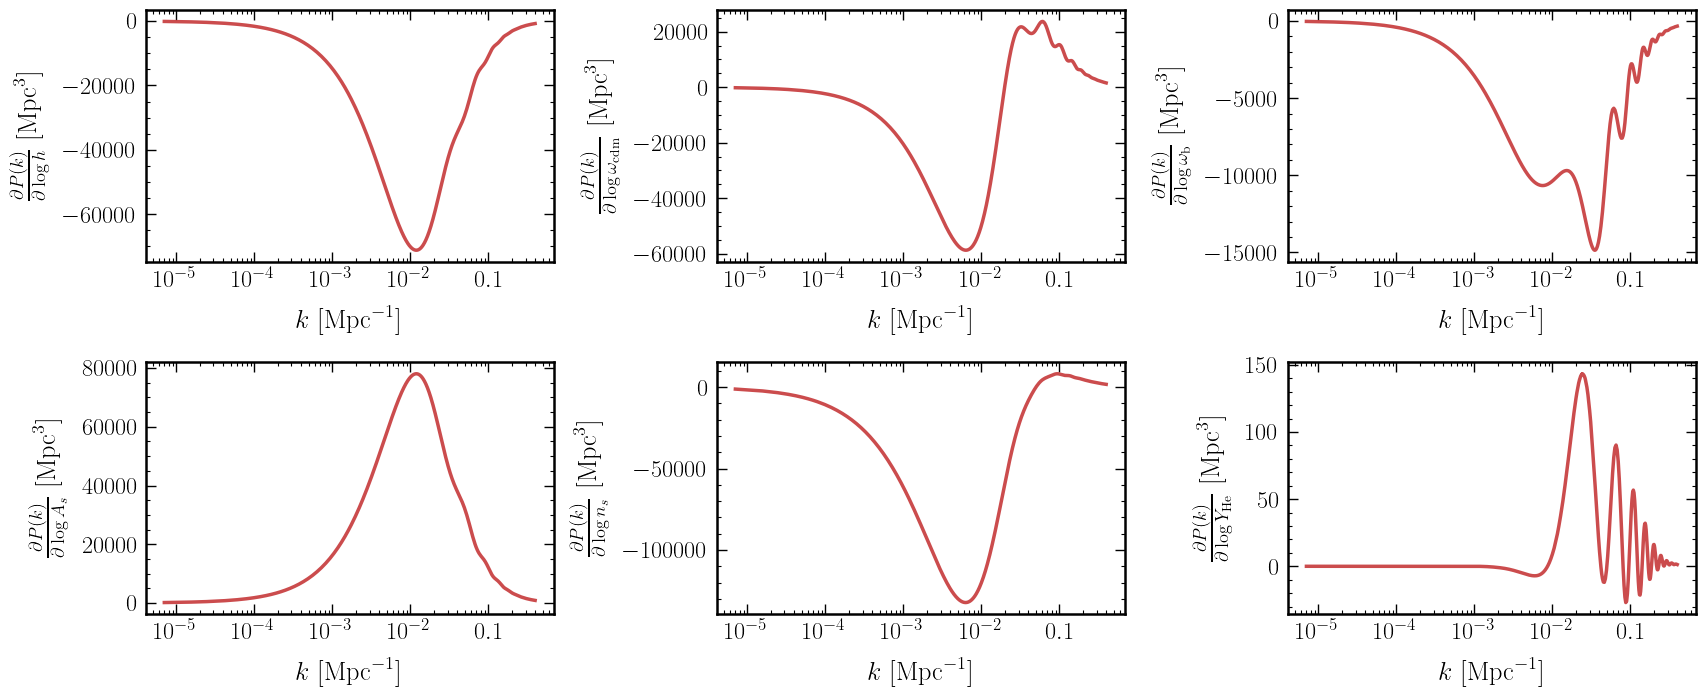

In [85]:
deri = ()
for i in range(6):
    deri += (np.loadtxt("derivatives/dPkd{}.txt".format(i)), )

fig, axs = plt.subplots(2, 3, figsize=(20, 8), dpi=100)
fig.subplots_adjust(wspace=0.4)  # default ~0.2
fig.subplots_adjust(hspace=0.4)  # default ~0.2

axs[0, 0].plot(k, deri[0]*params_lcdm["h"])
axs[0, 0].set_xscale("log")
axs[0, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 0].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{h}}\ [{\rm Mpc}^3]$")

axs[0, 1].plot(k, deri[1]*params_lcdm["omega_cdm"])
axs[0, 1].set_xscale("log")
axs[0, 1].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 1].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{\omega_{\rm cdm}}}\ [{\rm Mpc}^3]$")

axs[0, 2].plot(k, deri[2]*params_lcdm["omega_b"])
axs[0, 2].set_xscale("log")
axs[0, 2].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 2].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{\omega_{\rm b}}}\ [{\rm Mpc}^3]$")

axs[1, 0].plot(k, deri[3]*params_lcdm["A_s"])
axs[1, 0].set_xscale("log")
axs[1, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[1, 0].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{A_s}}\ [{\rm Mpc}^3]$")

axs[1, 1].plot(k, deri[4]*params_lcdm["n_s"])
axs[1, 1].set_xscale("log")
axs[1, 1].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[1, 1].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{n_s}}\ [{\rm Mpc}^3]$")

axs[1, 2].plot(k, deri[5]*params_lcdm["YHe"])
axs[1, 2].set_xscale("log")
axs[1, 2].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[1, 2].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{Y_{\rm He}}}\ [{\rm Mpc}^3]$")

plt.savefig("Plots/dPk.pdf", bbox_inches="tight")
plt.show()

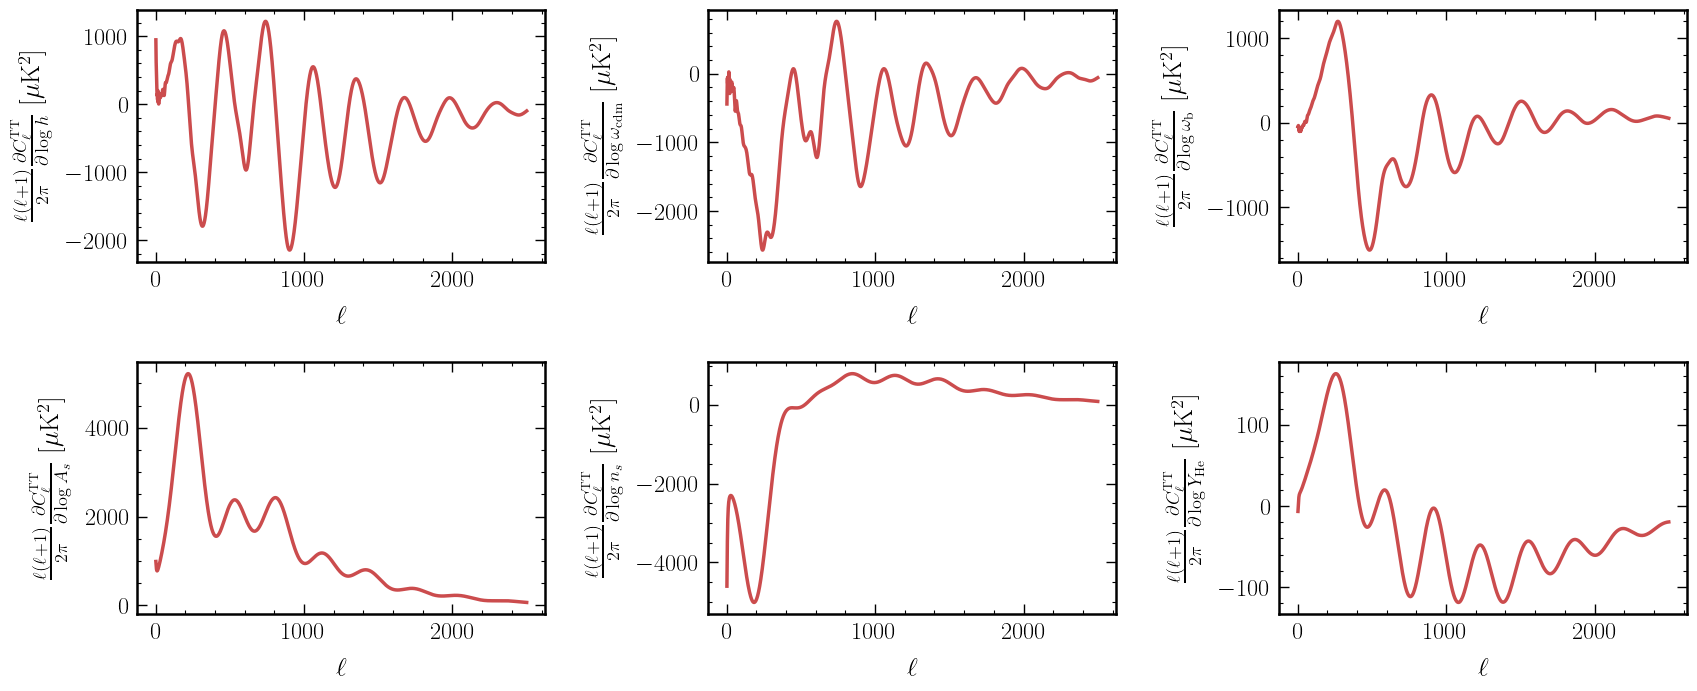

In [86]:
deri = ()
for i in range(6):
    deri += (np.loadtxt("derivatives/dttd{}.txt".format(i)), )

Cl_fac = l*(l+1)/2/jnp.pi * (2.7255e6)**2

fig, axs = plt.subplots(2, 3, figsize=(20, 8), dpi=100)
fig.subplots_adjust(wspace=0.4)  # default ~0.2
fig.subplots_adjust(hspace=0.4)  # default ~0.2

axs[0, 0].plot(l, deri[0]*Cl_fac*params_lcdm["h"])
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{h}}\ [\mu {\rm K}^2]$")

axs[0, 1].plot(l, deri[1]*Cl_fac*params_lcdm["omega_cdm"])
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{\omega_{\rm cdm}}}\ [\mu {\rm K}^2]$")

axs[0, 2].plot(l, deri[2]*Cl_fac*params_lcdm["omega_b"])
axs[0, 2].set_xlabel(r"$\ell$")
axs[0, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 0].plot(l, deri[3]*Cl_fac*params_lcdm["A_s"])
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{A_s}}\ [\mu {\rm K}^2]$")

axs[1, 1].plot(l, deri[4]*Cl_fac*params_lcdm["n_s"])
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{n_s}}\ [\mu {\rm K}^2]$")

axs[1, 2].plot(l, deri[5]*Cl_fac*params_lcdm["YHe"])
axs[1, 2].set_xlabel(r"$\ell$")
axs[1, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{Y_{\rm He}}}\ [\mu {\rm K}^2]$")

plt.savefig("Plots/dTT.pdf", bbox_inches="tight")
fig.show()

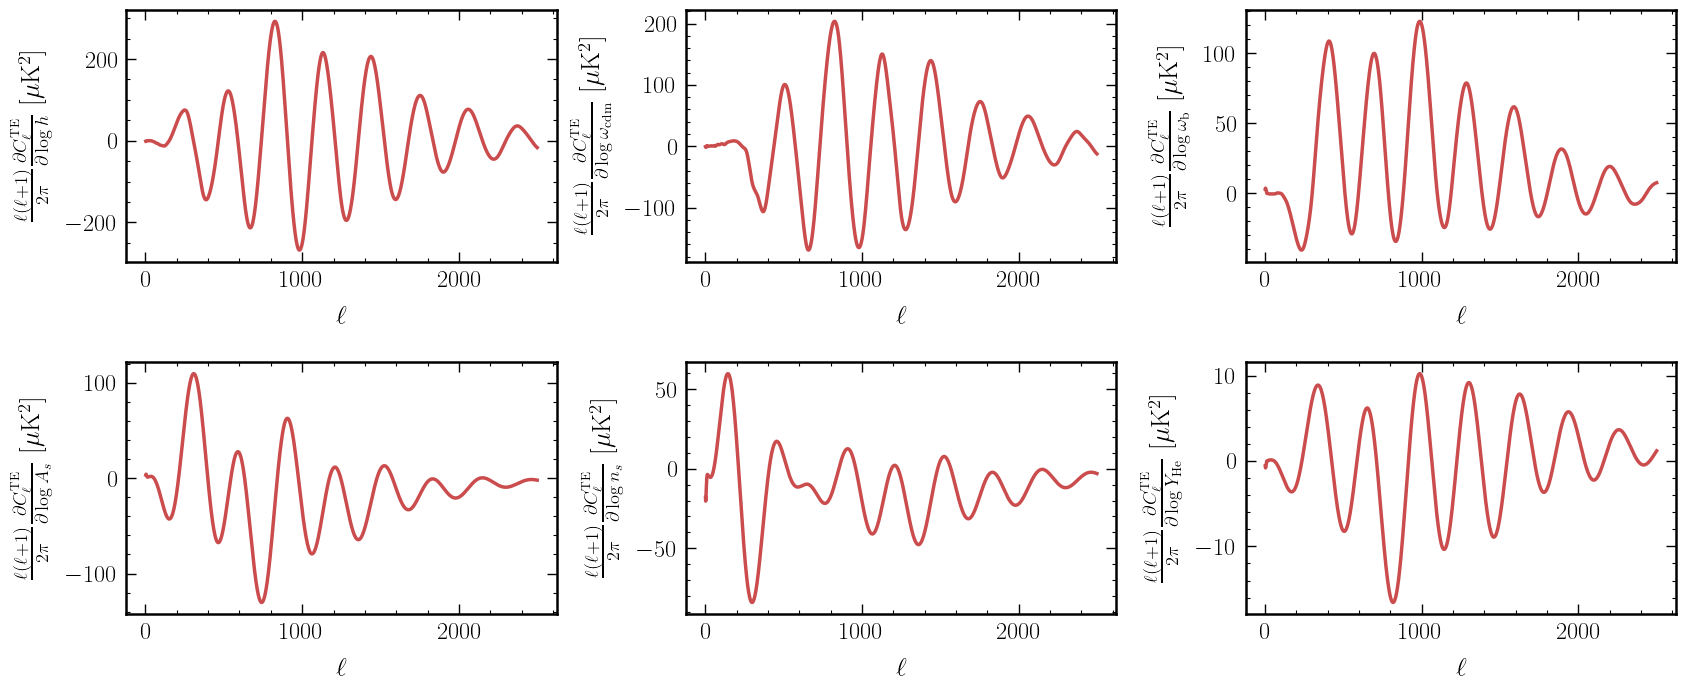

In [87]:
deri = ()
for i in range(6):
    deri += (np.loadtxt("derivatives/dted{}.txt".format(i)), )

Cl_fac = l*(l+1)/2/jnp.pi * (2.7255e6)**2

fig, axs = plt.subplots(2, 3, figsize=(20, 8), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.4)  # default ~0.2

axs[0, 0].plot(l, deri[0]*Cl_fac*params_lcdm["h"])
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{h}}\ [\mu {\rm K}^2]$")

axs[0, 1].plot(l, deri[1]*Cl_fac*params_lcdm["omega_cdm"])
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{\omega_{\rm cdm}}}\ [\mu {\rm K}^2]$")

axs[0, 2].plot(l, deri[2]*Cl_fac*params_lcdm["omega_b"])
axs[0, 2].set_xlabel(r"$\ell$")
axs[0, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 0].plot(l, deri[3]*Cl_fac*params_lcdm["A_s"])
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{A_s}}\ [\mu {\rm K}^2]$")

axs[1, 1].plot(l, deri[4]*Cl_fac*params_lcdm["n_s"])
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{n_s}}\ [\mu {\rm K}^2]$")

axs[1, 2].plot(l, deri[5]*Cl_fac*params_lcdm["YHe"])
axs[1, 2].set_xlabel(r"$\ell$")
axs[1, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{Y_{\rm He}}}\ [\mu {\rm K}^2]$")

plt.savefig("Plots/dTE.pdf", bbox_inches="tight")
fig.show()

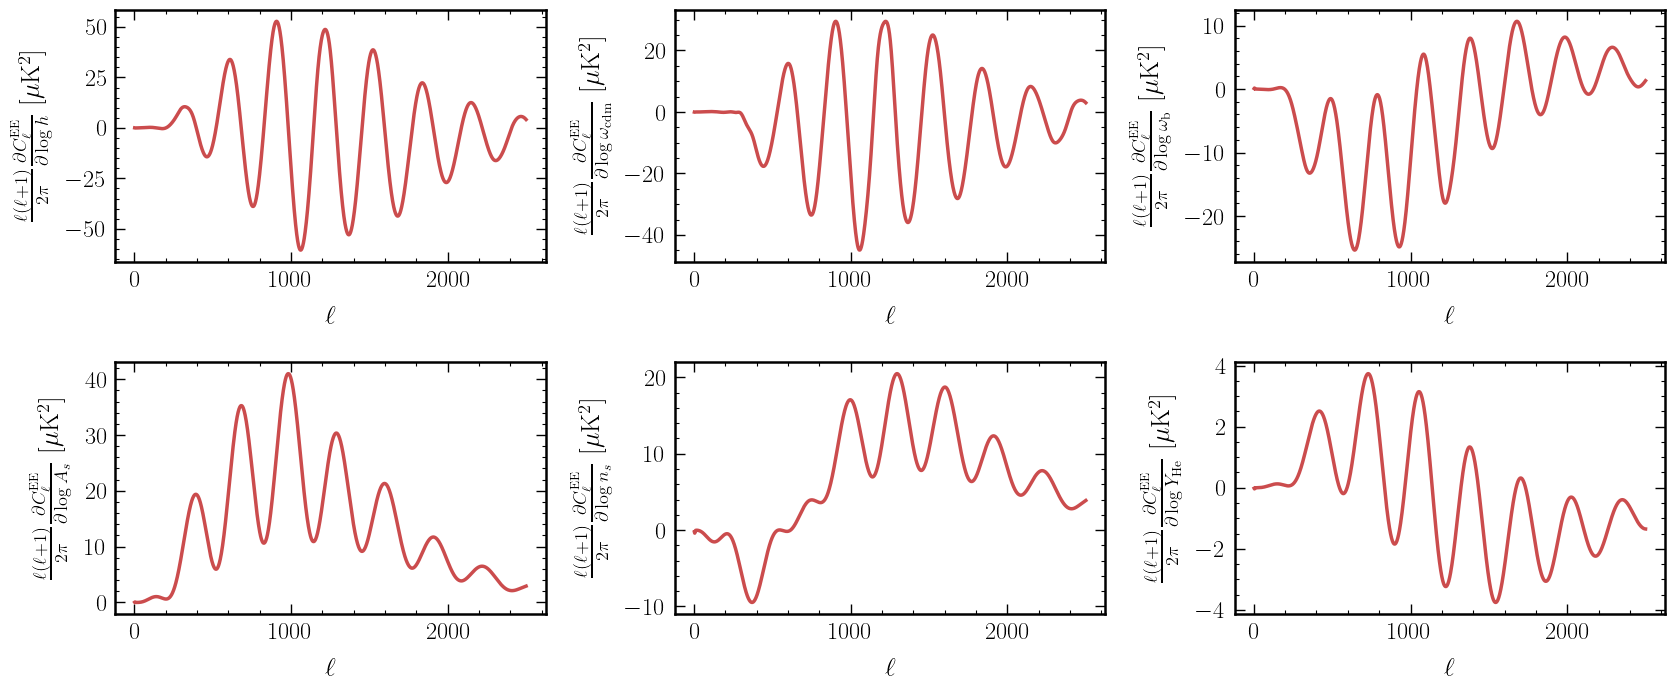

In [88]:
deri = ()
for i in range(6):
    deri += (np.loadtxt("derivatives/deed{}.txt".format(i)), )

Cl_fac = l*(l+1)/2/jnp.pi * (2.7255e6)**2

fig, axs = plt.subplots(2, 3, figsize=(20, 8), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.4)  # default ~0.2

axs[0, 0].plot(l, deri[0]*Cl_fac*params_lcdm["h"])
axs[0, 0].set_xlabel(r"$\ell$")
axs[0, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{h}}\ [\mu {\rm K}^2]$")

axs[0, 1].plot(l, deri[1]*Cl_fac*params_lcdm["omega_cdm"])
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{\omega_{\rm cdm}}}\ [\mu {\rm K}^2]$")

axs[0, 2].plot(l, deri[2]*Cl_fac*params_lcdm["omega_b"])
axs[0, 2].set_xlabel(r"$\ell$")
axs[0, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 0].plot(l, deri[3]*Cl_fac*params_lcdm["A_s"])
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{A_s}}\ [\mu {\rm K}^2]$")

axs[1, 1].plot(l, deri[4]*Cl_fac*params_lcdm["n_s"])
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{n_s}}\ [\mu {\rm K}^2]$")

axs[1, 2].plot(l, deri[5]*Cl_fac*params_lcdm["YHe"])
axs[1, 2].set_xlabel(r"$\ell$")
axs[1, 2].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{Y_{\rm He}}}\ [\mu {\rm K}^2]$")

plt.savefig("Plots/dEE.pdf", bbox_inches="tight")
fig.show()

## With LINX

In [65]:
specs =specs_unlensed.copy()
specs["bbn_type"] = "linx"
model = main.Model(specs)
params_lcdm = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

In [66]:
def f(omega_b):
    params = params_lcdm.copy()
    params["omega_b"] = omega_b
    return model.run_cosmology(params)

In [67]:
s = time.time()
deri, aux = jacfwd(f, has_aux=True)(
    params_lcdm["omega_b"],
)
print(time.time() - s)

`\         /´  ||||        ||||  |||||     ||||  ||||   ||||
 /\_______/\   ||||        ||||  |||||||   ||||   |||| ||||
 ) __` ´__ (   ||||        ||||  |||| |||| ||||    |||||||
/  `-|_|-´  \  ||||        ||||  ||||  |||| |||    ||||||| 
/   (_x_)   \  ||||||||||  ||||  ||||   |||||||   |||| ||||
  )  `-´  (    ||||||||||  ||||  ||||    ||||||  ||||   ||||
 
Compiling thermodynamics model...
Compiling abundance model...

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



E1216 17:33:23.384606 2509368 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_run_cosmology_abbr for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E1216 17:34:41.188809 2508897 slow_operation_alarm.cc:140] The operation took 3m17.804299967s

********************************
[Compiling module jit_run_cosmology_abbr for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


598.9826397895813


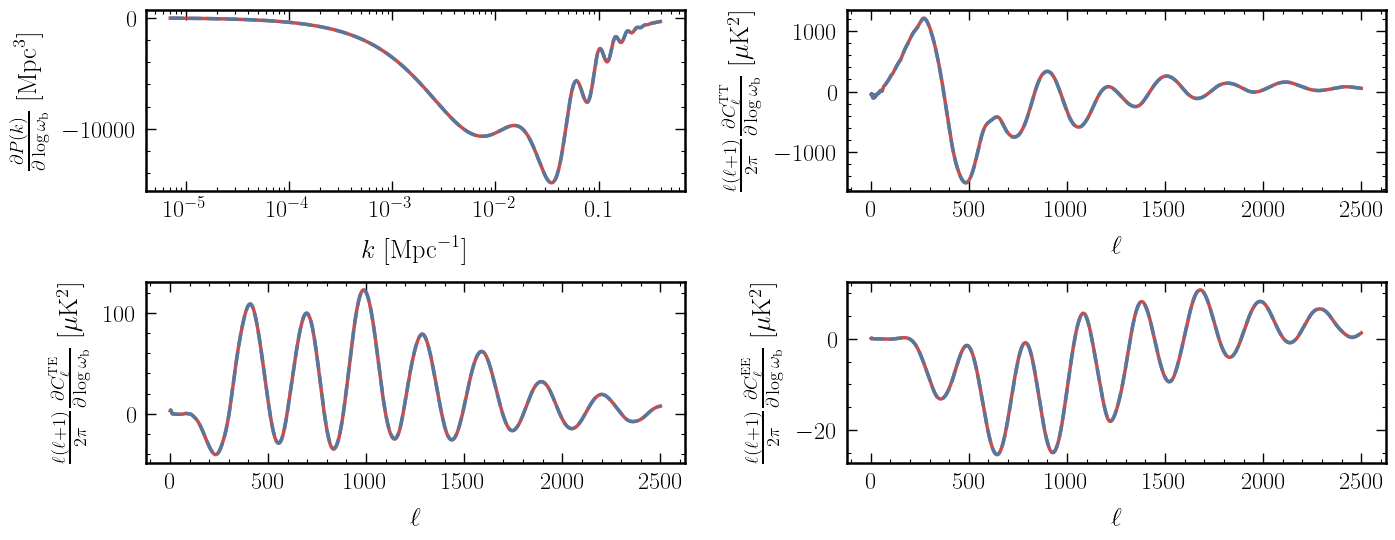

In [83]:
l = aux[0]
k = aux[1]
Cl_fac = l*(l+1)/2/jnp.pi * (2.7255e6)**2


fig, axs = plt.subplots(2, 2, figsize=(16, 6), dpi=100)
fig.subplots_adjust(wspace=0.3)  # default ~0.2
fig.subplots_adjust(hspace=0.5)  # default ~0.2

axs[0, 0].plot(k, deri[3]*params_lcdm["omega_b"])
axs[0, 0].plot(k, deri_old[3]*params_lcdm["omega_b"], "--")
axs[0, 0].set_xscale("log")
axs[0, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 0].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{\omega_{\rm b}}}\ [{\rm Mpc}^3]$")

axs[0, 1].plot(l, deri[0]*Cl_fac*params_lcdm["omega_b"])
axs[0, 1].plot(l, deri_old[0]*Cl_fac*params_lcdm["omega_b"], "--")
axs[0, 1].set_xlabel(r"$\ell$")
axs[0, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 0].plot(l, deri[1]*Cl_fac*params_lcdm["omega_b"])
axs[1, 0].plot(l, deri_old[1]*Cl_fac*params_lcdm["omega_b"], "--")
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 1].plot(l, deri[2]*Cl_fac*params_lcdm["omega_b"])
axs[1, 1].plot(l, deri_old[2]*Cl_fac*params_lcdm["omega_b"], "--")
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

plt.savefig("Plots/deri_linx.pdf", bbox_inches="tight")
fig.show()

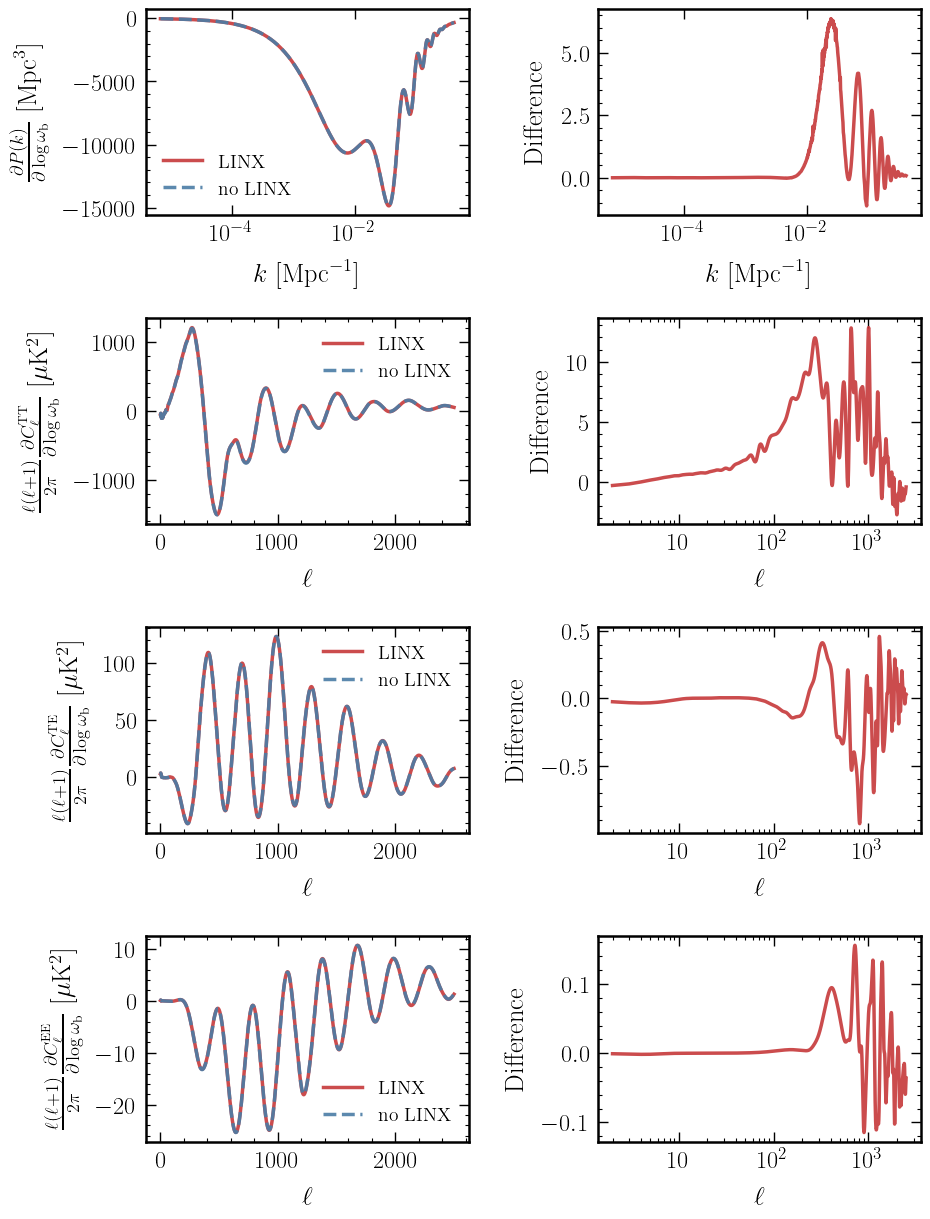

In [98]:
l = aux[0]
k = aux[1]
Cl_fac = l*(l+1)/2/jnp.pi * (2.7255e6)**2


fig, axs = plt.subplots(4, 2, figsize=(10, 15), dpi=100)
fig.subplots_adjust(wspace=0.4)  # default ~0.2
fig.subplots_adjust(hspace=0.5)  # default ~0.2

axs[0, 0].plot(k, deri[3]*params_lcdm["omega_b"], label="LINX")
axs[0, 0].plot(k, deri_old[3]*params_lcdm["omega_b"], "--", label="no LINX")
axs[0, 0].set_xscale("log")
axs[0, 0].legend(fontsize=14)
axs[0, 0].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 0].set_ylabel(r"$\frac{\partial P(k)}{\partial \log{\omega_{\rm b}}}\ [{\rm Mpc}^3]$")

axs[0, 1].plot(k, (deri[3]-deri_old[3])*params_lcdm["omega_b"])
axs[0, 1].set_xscale("log")
axs[0, 1].set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
axs[0, 1].set_ylabel("Difference")

axs[1, 0].plot(l, deri[0]*Cl_fac*params_lcdm["omega_b"], label="LINX")
axs[1, 0].plot(l, deri_old[0]*Cl_fac*params_lcdm["omega_b"], "--", label="no LINX")
axs[1, 0].legend(fontsize=14)
axs[1, 0].set_xlabel(r"$\ell$")
axs[1, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TT}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[1, 1].plot(l, (deri[0]-deri_old[0])*Cl_fac*params_lcdm["omega_b"])
axs[1, 1].set_xscale("log")
axs[1, 1].set_xlabel(r"$\ell$")
axs[1, 1].set_ylabel("Difference")

axs[2, 0].plot(l, deri[1]*Cl_fac*params_lcdm["omega_b"], label="LINX")
axs[2, 0].plot(l, deri_old[1]*Cl_fac*params_lcdm["omega_b"], "--", label="no LINX")
axs[2, 0].legend(fontsize=14)
axs[2, 0].set_xlabel(r"$\ell$")
axs[2, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm TE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[2, 1].plot(l, (deri[1]-deri_old[1])*Cl_fac*params_lcdm["omega_b"])
axs[2, 1].set_xscale("log")
axs[2, 1].set_xlabel(r"$\ell$")
axs[2, 1].set_ylabel("Difference")

axs[3, 0].plot(l, deri[2]*Cl_fac*params_lcdm["omega_b"], label="LINX")
axs[3, 0].plot(l, deri_old[2]*Cl_fac*params_lcdm["omega_b"], "--", label="no LINX")
axs[3, 0].legend(fontsize=14)
axs[3, 0].set_xlabel(r"$\ell$")
axs[3, 0].set_ylabel(r"$\frac{\ell (\ell+1)}{2\pi}\frac{\partial C_{\ell}^{\rm EE}}{\partial \log{\omega_{\rm b}}}\ [\mu {\rm K}^2]$")

axs[3, 1].plot(l, (deri[2]-deri_old[2])*Cl_fac*params_lcdm["omega_b"])
axs[3, 1].set_xscale("log")
axs[3, 1].set_xlabel(r"$\ell$")
axs[3, 1].set_ylabel("Difference")

plt.savefig("Plots/deri_linx.pdf", bbox_inches="tight")
fig.show()

In [77]:
deri_old = (
    np.loadtxt("derivatives/dttd2.txt"),
    np.loadtxt("derivatives/dted2.txt"),
    np.loadtxt("derivatives/deed2.txt"),
    np.loadtxt("derivatives/dPkd2.txt"),
)

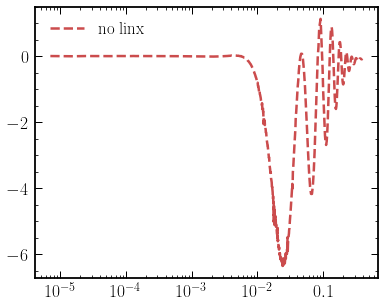

In [72]:
#plt.plot(aux[1], deri[3]*0.0225, label="linx")
plt.plot(aux[1], deri_old[0] - deri[3]*0.0225, "--", label="no linx")
plt.xscale("log")
plt.legend()
plt.show()

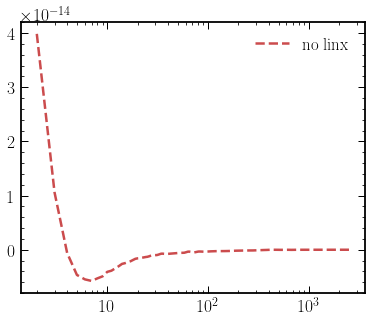

In [73]:
#plt.plot(aux[1], deri[3]*0.0225, label="linx")
plt.plot(aux[0], deri_old[1] - deri[0]*0.0225, "--", label="no linx")
plt.xscale("log")
plt.legend()
plt.show()